In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score, f1_score, precision_recall_curve, average_precision_score
from catboost import CatBoostClassifier, Pool
import altair as alt
import warnings

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
alt.renderers.enable('default')

RendererRegistry.enable('default')

In [3]:
df = pd.read_csv('train_transaction.csv')

In [4]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.shape

(590540, 394)

In [6]:
print('%20s %18s %18s %6s' %('Имя', 'Тип данных', 'Кол-во пропусков', '%'))
for col in df.columns[:17]:
    print('%20s %15s %13d %15.1f' %(col, df[col].dtypes, df[col].isna().sum(), df[col].isna().sum() / df.shape[0] * 100))

                 Имя         Тип данных   Кол-во пропусков      %
       TransactionID           int64             0             0.0
             isFraud           int64             0             0.0
       TransactionDT           int64             0             0.0
      TransactionAmt         float64             0             0.0
           ProductCD          object             0             0.0
               card1           int64             0             0.0
               card2         float64          8933             1.5
               card3         float64          1565             0.3
               card4          object          1577             0.3
               card5         float64          4259             0.7
               card6          object          1571             0.3
               addr1         float64         65706            11.1
               addr2         float64         65706            11.1
               dist1         float64        352271            5

In [7]:
ident_df = pd.read_csv('train_identity.csv')

In [8]:
ident_df.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [9]:
print('%20s %18s %18s %6s' %('Имя', 'Тип данных', 'Кол-во пропусков', '%'))
for col in ident_df.columns:
    print('%20s %15s %13d %15.1f' %(col, ident_df[col].dtypes, ident_df[col].isna().sum(), ident_df[col].isna().sum() / ident_df.shape[0] * 100))

                 Имя         Тип данных   Кол-во пропусков      %
       TransactionID           int64             0             0.0
               id_01         float64             0             0.0
               id_02         float64          3361             2.3
               id_03         float64         77909            54.0
               id_04         float64         77909            54.0
               id_05         float64          7368             5.1
               id_06         float64          7368             5.1
               id_07         float64        139078            96.4
               id_08         float64        139078            96.4
               id_09         float64         69307            48.1
               id_10         float64         69307            48.1
               id_11         float64          3255             2.3
               id_12          object             0             0.0
               id_13         float64         16913            1

In [10]:
data = df.merge(ident_df, how='left', on='TransactionID')

In [11]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Для экономии памяти сменим разрядность числовых столбцов:

In [12]:
float_cols = data.select_dtypes(include=['float64']).columns
data[float_cols] = data[float_cols].astype('float32')

int_cols = data.select_dtypes(include=['int64']).columns
data[int_cols] = data[int_cols].astype('int32')

In [13]:
data.shape

(590540, 434)

**Перейдем к разведочному анализу данных (EDA)**

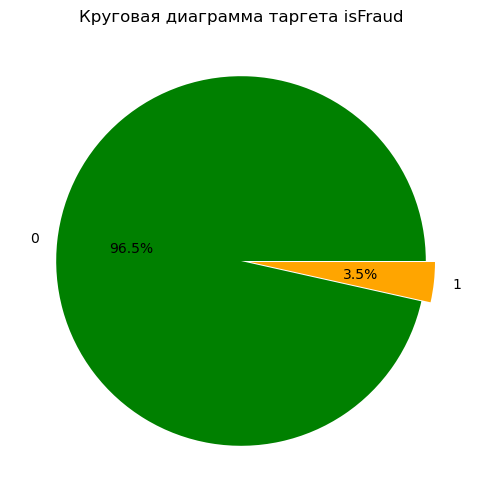

In [14]:
plt.figure(figsize=(10, 6))
plt.pie(
    data.isFraud.value_counts(),
    labels=data.isFraud.value_counts().index,
    autopct='%1.1f%%',
    colors=['green', 'orange'],
    explode=(0, 0.05)
)
plt.title('Круговая диаграмма таргета isFraud')
plt.show()

**Сильный дисбаланс классов - фрод встречается всего в 3.5% выборки. Учтем при обучении модели**

In [15]:
data['day'] = data['TransactionDT'] // (60 * 60 * 24)
data['hour'] = (data['TransactionDT'] // 3600) % 24
data['weekday'] = data['day'] % 7
data['is_night'] = data['hour'].isin([0,1,2,3,4,5,6]).astype(int)

daily_stats = (
    data.groupby('day')
      .agg(
          total_tx=('isFraud', 'count'),
          fraud_tx=('isFraud', 'sum')
      )
      .reset_index()
)

daily_stats['fraud_rate'] = daily_stats['fraud_tx'] / daily_stats['total_tx']

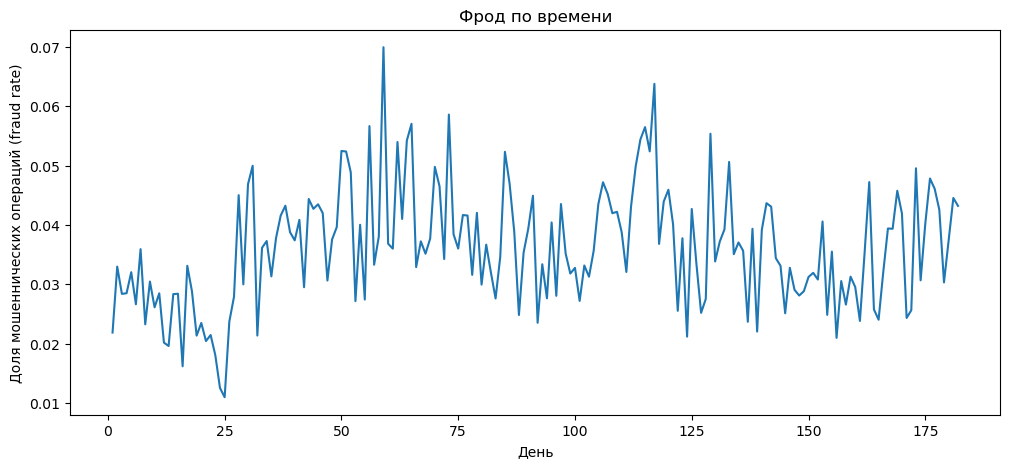

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['day'], daily_stats['fraud_rate'])
plt.xlabel('День')
plt.ylabel('Доля мошеннических операций (fraud rate)')
plt.title('Фрод по времени')
plt.show()

Зависимость мошеннических операций от времени нестационарна, на диаграмме присутствуют явные пики, вследствие чего требуется временная кросс-валидация и мониторинг data drift

<Axes: xlabel='log_amt', ylabel='Density'>

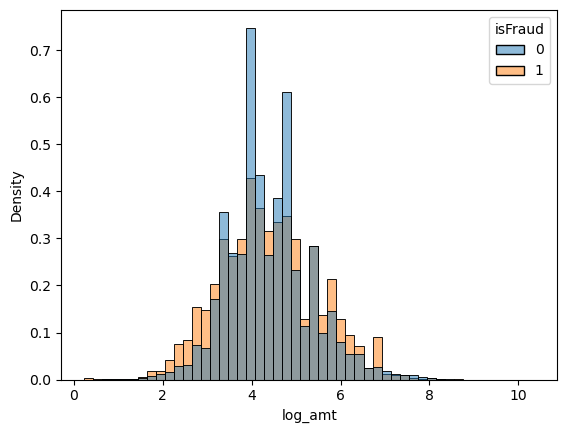

In [17]:
data['log_amt'] = np.log1p(data['TransactionAmt'])
sns.histplot(
    data=data,
    x='log_amt',
    hue='isFraud',
    bins=50,
    stat='density',
    common_norm=False
)

Фрод чаще встречается в средних и высоких суммах транзакций, однако, дублирование с легитимными операциями все же присутствует => нет полноценного разделения операций по суммам

Исследуем корреляции признаков с разбиением по дням (5 фолдов по 36 дней)

In [18]:
num_data = data.select_dtypes(include=[np.number]).copy()
n_folds = 6

days = np.array(sorted(num_data["day"].dropna().unique()))
day_folds = np.array_split(days, n_folds)

fold_corrs = []

for i, fold_days in enumerate(day_folds, start=1):
    fold_df = num_data[num_data["day"].isin(fold_days)]

    corr_with_target = (
        fold_df.corr(numeric_only=True)["isFraud"]
        .drop("isFraud", errors="ignore")
    )

    fold_corrs.append(corr_with_target.rename(f"fold_{i}"))


corr_table = pd.concat(fold_corrs, axis=1)

corr_table["mean_abs_corr"] = corr_table.abs().mean(axis=1)
corr_table = corr_table.sort_values("mean_abs_corr", ascending=False)



display(corr_table.head(30))

,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,mean_abs_corr
V257,0.303625,0.380712,0.372977,0.396451,0.408301,0.437378,0.383241
V246,0.264921,0.409980,0.333347,0.424002,0.384172,0.423617,0.373340
V258,0.119141,0.425720,0.387583,0.404345,0.402798,0.443984,0.363929
V244,0.254087,0.391527,0.386193,0.402620,0.366411,0.380340,0.363530
V242,0.235555,0.384500,0.391726,0.413902,0.368733,0.381372,0.362631
V243,0.084332,0.417014,0.391444,0.415477,0.369246,0.385205,0.343786
V201,0.337416,0.332475,0.327041,0.299251,0.285745,0.400180,0.330351
V200,0.303555,0.310962,0.316857,0.319532,0.305543,0.363478,0.319988
V189,0.319056,0.353892,0.301789,0.249461,0.314764,0.340576,0.313257
V188,0.280953,0.327249,0.317413,0.310518,0.323032,0.317260,0.312737


Заметен дрифт в данных (пример - признак V258, фолд1 = 0.13, фолд5 = 442). Важно учесть при обучении и в продакшене

Несколько анонимных V-признаков показывают относительно сильную корреляцию с ярлыком мошенничества, указывая на то, что они фиксируют значимые транзакционные модели, связанные с мошенническим поведением.  

<Axes: xlabel='day'>

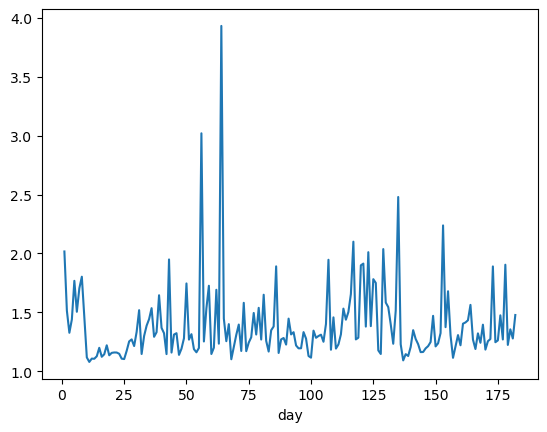

In [19]:
data.groupby("day")["V258"].mean().plot()

Временной анализ признака V258 показывает значительную нестационарность. Функция становится более предсказуемой в более поздние периоды, указывая на эволюцию мошенничества

In [20]:
cat_cols = ['ProductCD', 'card4', 'card6', 'M4', 'M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9']

charts = []
for col in cat_cols:
    vc = (
        data[col]
        .fillna("__MISSING__")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )

    chart = (
        alt.Chart(vc)
        .mark_bar()
        .encode(
            y=alt.Y(f"{col}:N", sort='-x', title=col),
            x=alt.X("count:Q", title="Count"),
            tooltip=[alt.Tooltip(f"{col}:N", title=col), alt.Tooltip("count:Q", title="Count")]
        )
        .properties(title=f"Counts of {col}", width=400, height=180)
    )
    charts.append(chart)

grid = alt.vconcat(*[
    alt.hconcat(*charts[i:i+2]) for i in range(0, len(charts), 2)
]).resolve_scale(y='independent')

grid

alt.VConcatChart(...)

Можем распознать признаки: card6 это тип карты; card4 - платежная система карты

Перейдем к подготовке данных, удаляем признаки с 80% пропусков и признаки-константы:

In [21]:
big_top_value_cols = [
    col for col in data.columns
    if data[col].value_counts(dropna=False, normalize=True).values[0] > 0.9
]

one_value_cols = [
    col for col in data.columns
    if data[col].nunique() <= 1
]

thresh = 0.80 
X_less_nas = data.dropna(thresh=data.shape[0]*(1-thresh), axis='columns')
cols_dropped  = list(set(data.columns)-set(X_less_nas.columns))

cols_to_drop = list(set(cols_dropped + big_top_value_cols + one_value_cols))
cols_to_drop.remove('isFraud')

In [22]:
data_for_model = data.drop(cols_to_drop, axis=1)

In [23]:
del df, data, ident_df, X_less_nas

In [24]:
data_for_model.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_36,id_37,id_38,DeviceType,DeviceInfo,day,hour,weekday,is_night,log_amt
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1,4.241327
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1,3.401197
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1,4.094345
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,1,0,1,1,3.931826
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1,0,1,1,3.931826


**Feature Engineering: создаем новые признаки**

In [25]:
data_for_model["TransactionAmt_log"] = np.log1p(data_for_model["TransactionAmt"]).astype("float32")

columns_a = ["TransactionAmt", "TransactionAmt_log"]
columns_b = ["card1", "card4", "addr1"]

eps = np.float32(1e-6)

for col_b in columns_b:
    for col_a in columns_a:
        data_for_model[f"{col_a}_to_mean_{col_b}"] = np.nan
        data_for_model[f"{col_a}_to_std_{col_b}"]  = np.nan

seen_days = np.array([], dtype=data_for_model["day"].dtype)

for fold_days in day_folds:
    train_days = seen_days
    seen_days = np.concatenate([seen_days, fold_days])

    val_mask = data_for_model["day"].isin(fold_days)

    if train_days.size == 0:
        continue

    train_df = data_for_model[data_for_model["day"].isin(train_days)]

    for col_b in columns_b:
        agg_mean = train_df.groupby(col_b)[columns_a].mean().astype("float32")
        agg_var  = train_df.groupby(col_b)[columns_a].var().astype("float32")
        agg_std  = np.sqrt(agg_var).astype("float32")

        agg_std = agg_std.mask(agg_std < eps, np.nan)

        for col_a in columns_a:
            mean_map = data_for_model.loc[val_mask, col_b].map(agg_mean[col_a]) + eps
            std_map  = data_for_model.loc[val_mask, col_b].map(agg_std[col_a]) + eps

            x = data_for_model.loc[val_mask, col_a].astype("float32")

            data_for_model.loc[val_mask, f"{col_a}_to_mean_{col_b}"] = (x / mean_map.astype("float32")).astype("float32")
            data_for_model.loc[val_mask, f"{col_a}_to_std_{col_b}"]  = (x / std_map.astype("float32")).astype("float32")

Добавляем флаг совпадения доменов:

In [26]:
def add_email_domain_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()


    df["P_email_root"] = df["P_emaildomain"].str.split(".", n=1, expand=True)[0]
    df["R_email_root"] = df["R_emaildomain"].str.split(".", n=1, expand=True)[0]

    p_missing = df["P_emaildomain"].isna() | df["P_emaildomain"].eq("__MISSING__")
    r_missing = df["R_emaildomain"].isna() | df["R_emaildomain"].eq("__MISSING__")

    df["email_both_present"] = (~p_missing & ~r_missing).astype(int)
    df["email_any_missing"]  = (p_missing | r_missing).astype(int)

    df["email_domain_match"] = (df["P_emaildomain"] == df["R_emaildomain"]).astype(int)
    df["email_root_match"]   = (df["P_email_root"] == df["R_email_root"]).astype(int)

    df["email_only_P"] = (~p_missing & r_missing).astype(int)
    df["email_only_R"] = (p_missing & ~r_missing).astype(int)

    return df

data_for_model = add_email_domain_flags(data_for_model)

In [27]:
data_for_model[["P_emaildomain_1", "P_emaildomain_2", "P_emaildomain_3"]] = (
    data_for_model["P_emaildomain"].str.split(".", expand=True)
)

data_for_model[["R_emaildomain_1", "R_emaildomain_2", "R_emaildomain_3"]] = (
    data_for_model["R_emaildomain"].str.split(".", expand=True)
)

Заполнение пропущенных значений

In [28]:
num_cols = data_for_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data_for_model.select_dtypes(include=["object"]).columns.tolist()
data_for_model[cat_cols] = data_for_model[cat_cols].fillna("__MISSING__").astype(str)

In [29]:
data_for_model.isnull().sum().sum()

np.int64(70190419)

Подготавливаем данные для Catboost

In [30]:
data_for_model = data_for_model.sort_values("day").reset_index(drop=True)

target_col = "isFraud"
time_col = "day"

X = data_for_model.drop(columns=[target_col, 'TransactionID'])
y = data_for_model[target_col].astype(int)

cat_features = [col for col in X.columns if str(X[col].dtype) in ["object", "category"]]

In [31]:
freq_cols = [
    'card1','card2','card3','card4','card5','card6',
    'addr1','addr2','ProductCD','P_emaildomain','R_emaildomain',
    'DeviceType','DeviceInfo'
]
freq_cols = [c for c in freq_cols if c in X.columns]

for c in freq_cols:
    X[f'FE_{c}'] = np.nan

fold_indices = []
seen_days = np.array([], dtype=X['day'].dtype)
for val_days in day_folds:
    val_days = np.array(val_days)
    train_days = seen_days
    seen_days = np.concatenate([seen_days, val_days])
    if train_days.size == 0:
        continue
    train_idx = np.flatnonzero(X['day'].isin(train_days).values)
    val_idx   = np.flatnonzero(X['day'].isin(val_days).values)
    fold_indices.append((train_idx, val_idx))

for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):
    X_tr = X.iloc[train_idx]
    X_va = X.iloc[val_idx]
    for c in freq_cols:
        freq_map = X_tr[c].value_counts(dropna=False)
        X.iloc[val_idx, X.columns.get_loc(f'FE_{c}')] = X_va[c].map(freq_map)

for c in freq_cols:
    X[f'FE_{c}'] = X[f'FE_{c}'].fillna(0).astype('float32')

Обучение модели. Для учета дисбаланса добавляем гиперпараметр scale_pos_weight - множитель веса для положительного класса

Модель с подбором порога класссификации:

In [32]:
# auc_train_list, auc_val_list = [], []
# pr_auc_train_list, pr_auc_val_list = [], []
# precision_list, recall_list = [], []
# accuracy_list, f1_list = [], []
# threshold_list = []

# fold_indices = []
# seen_days = np.array([], dtype=days.dtype)

# for val_days in day_folds:
#     val_days = np.array(val_days)

#     train_days = seen_days
#     seen_days = np.concatenate([seen_days, val_days])


#     if train_days.size == 0:
#         continue

#     train_idx = np.flatnonzero(X["day"].isin(train_days).values)
#     val_idx   = np.flatnonzero(X["day"].isin(val_days).values)

#     fold_indices.append((train_idx, val_idx))

# for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):

#     print(f"\n===== Fold {fold} =====")

#     X_train, X_val = X.iloc[train_idx].drop('day', axis=1), X.iloc[val_idx].drop('day', axis=1)
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     n_pos = int((y_train == 1).sum())
#     n_neg = int((y_train == 0).sum())
#     spw = n_neg / n_pos if n_pos > 0 else 1.0

#     model = CatBoostClassifier(
#         iterations=2000,
#         learning_rate=0.03,
#         depth=5,
#         loss_function="Logloss",
#         eval_metric="AUC",
#         l2_leaf_reg=30,
#         random_strength=5,
#         random_state=42,
#         min_data_in_leaf=50,
#         scale_pos_weight=spw,
#         early_stopping_rounds=100,
#         use_best_model=True,
#         verbose=200,
#         task_type="GPU",
#         devices="0"
#     )

#     model.fit(
#         X_train, y_train,
#         cat_features=cat_features,
#         eval_set=(X_val, y_val)
#     )

#     y_train_pred_prob = model.predict_proba(X_train)[:, 1]
#     y_val_pred_prob   = model.predict_proba(X_val)[:, 1]

#     auc_train = roc_auc_score(y_train, y_train_pred_prob)
#     auc_val   = roc_auc_score(y_val, y_val_pred_prob)
#     auc_train_list.append(auc_train)
#     auc_val_list.append(auc_val)

#     pr_auc_train = average_precision_score(y_train, y_train_pred_prob)
#     pr_auc_val   = average_precision_score(y_val, y_val_pred_prob)
#     pr_auc_train_list.append(pr_auc_train)
#     pr_auc_val_list.append(pr_auc_val)

#     precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_val_pred_prob)
    
#     precision_t = precision_curve[1:]
#     recall_t = recall_curve[1:]
#     thresholds_t = thresholds
    
#     f1_arr = 2 * precision_t * recall_t / (precision_t + recall_t + 1e-12)
#     best_idx = int(np.argmax(f1_arr))
#     best_threshold = float(thresholds_t[best_idx])
    
#     y_val_pred = (y_val_pred_prob >= best_threshold).astype(int)
#     threshold_list.append(best_threshold)
    
#     print(f"Best thr (F1): {best_threshold:.6f}")
#     precision_fold = precision_score(y_val, y_val_pred, zero_division=0)
#     recall_fold = recall_score(y_val, y_val_pred, zero_division=0)
#     f1_fold = f1_score(y_val, y_val_pred, zero_division=0)
#     acc_fold = accuracy_score(y_val, y_val_pred)

#     precision_list.append(precision_fold)
#     recall_list.append(recall_fold)
#     accuracy_list.append(acc_fold)
#     f1_list.append(f1_fold)


# print("\n===== Итоговые средние метрики =====")
# print(f"Средний Train ROC AUC: {np.mean(auc_train_list):.4f}")
# print(f"Средний Val ROC AUC:   {np.mean(auc_val_list):.4f}")

# gap = np.mean(
#     np.abs(np.array(auc_val_list) - np.array(auc_train_list))
#     / np.array(auc_train_list)
# ) * 100
# print(f"Среднее расхождение (с train): {gap:.2f}%")

# print(f"Средний Train PR-AUC:  {np.mean(pr_auc_train_list):.4f}")
# print(f"Средний Val PR-AUC:    {np.mean(pr_auc_val_list):.4f}")
# print(f"Средний Precision: {np.mean(precision_list):.4f}")
# print(f"Средний Recall:    {np.mean(recall_list):.4f}")
# print(f"Средняя Accuracy:  {np.mean(accuracy_list):.4f}")
# print(f"Средний F1-score:  {np.mean(f1_list):.4f}")
# print(f"Threshold (mean):   {np.mean(threshold_list):.6f} (± {np.std(threshold_list):.6f})")
# print(f"Threshold (median): {np.median(threshold_list):.6f}")




**При threshold = 0.43 получаем recall 0.73, precision 0.24 (отлавливает 73% мошеннических операций, однако на 4 заблокированные операции только 1 истинно мошенническая)  
При threshold = 0.8 получаем recall 0.48, precision 0.59 (отлавливаем 48% мошенников, точность 59%)**



Обучение конечной модели:

In [33]:
auc_train_list, auc_val_list = [], []
pr_auc_train_list, pr_auc_val_list = [], []
precision_list, recall_list = [], []
accuracy_list, f1_list = [], []
threshold_list = []

fixed_threshold = 0.8

fold_indices = []
seen_days = np.array([], dtype=days.dtype)

for val_days in day_folds:
    val_days = np.array(val_days)

    train_days = seen_days
    seen_days = np.concatenate([seen_days, val_days])


    if train_days.size == 0:
        continue

    train_idx = np.flatnonzero(X["day"].isin(train_days).values)
    val_idx   = np.flatnonzero(X["day"].isin(val_days).values)

    fold_indices.append((train_idx, val_idx))

for fold, (train_idx, val_idx) in enumerate(fold_indices, 1):

    print(f"\n===== Fold {fold} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    spw = n_neg / n_pos if n_pos > 0 else 1.0

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        l2_leaf_reg=30,
        random_strength=5,
        random_state=42,
        min_data_in_leaf=50,
        scale_pos_weight=spw,
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=200,
        task_type="GPU",
        devices="0"
    )

    model.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val)
    )

    y_train_pred_prob = model.predict_proba(X_train)[:, 1]
    y_val_pred_prob   = model.predict_proba(X_val)[:, 1]

    auc_train = roc_auc_score(y_train, y_train_pred_prob)
    auc_val   = roc_auc_score(y_val, y_val_pred_prob)
    auc_train_list.append(auc_train)
    auc_val_list.append(auc_val)

    pr_auc_train = average_precision_score(y_train, y_train_pred_prob)
    pr_auc_val   = average_precision_score(y_val, y_val_pred_prob)
    pr_auc_train_list.append(pr_auc_train)
    pr_auc_val_list.append(pr_auc_val)

    y_val_pred = (y_val_pred_prob >= fixed_threshold).astype(int)
    threshold_list.append(fixed_threshold)


    precision_fold = precision_score(y_val, y_val_pred, zero_division=0)
    recall_fold = recall_score(y_val, y_val_pred, zero_division=0)
    f1_fold = f1_score(y_val, y_val_pred, zero_division=0)
    acc_fold = accuracy_score(y_val, y_val_pred)

    precision_list.append(precision_fold)
    recall_list.append(recall_fold)
    accuracy_list.append(acc_fold)
    f1_list.append(f1_fold)


print("\n===== Итоговые средние метрики =====")
print(f"Средний Train ROC AUC: {np.mean(auc_train_list):.4f}")
print(f"Средний Val ROC AUC:   {np.mean(auc_val_list):.4f}")

gap = np.mean(
    np.abs(np.array(auc_val_list) - np.array(auc_train_list))
    / np.array(auc_train_list)
) * 100
print(f"Среднее расхождение (с train): {gap:.2f}%")

print(f"Средний Train PR-AUC:  {np.mean(pr_auc_train_list):.4f}")
print(f"Средний Val PR-AUC:    {np.mean(pr_auc_val_list):.4f}")
print(f"Средний Precision: {np.mean(precision_list):.4f}")
print(f"Средний Recall:    {np.mean(recall_list):.4f}")
print(f"Средняя Accuracy:  {np.mean(accuracy_list):.4f}")
print(f"Средний F1-score:  {np.mean(f1_list):.4f}")
print(f"Threshold (mean):  {np.mean(threshold_list):.4f}")


===== Fold 1 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7891812	best: 0.7891812 (0)	total: 306ms	remaining: 10m 11s
200:	test: 0.8750126	best: 0.8750126 (200)	total: 19.9s	remaining: 2m 58s
400:	test: 0.8851479	best: 0.8851479 (400)	total: 39.4s	remaining: 2m 37s
600:	test: 0.8914958	best: 0.8916516 (594)	total: 58.8s	remaining: 2m 16s
800:	test: 0.8943896	best: 0.8944911 (795)	total: 1m 18s	remaining: 1m 57s
1000:	test: 0.8956760	best: 0.8959614 (982)	total: 1m 38s	remaining: 1m 38s
1200:	test: 0.8967687	best: 0.8968614 (1160)	total: 1m 58s	remaining: 1m 18s
1400:	test: 0.8976986	best: 0.8977581 (1392)	total: 2m 17s	remaining: 58.9s
1600:	test: 0.8976787	best: 0.8983732 (1534)	total: 2m 37s	remaining: 39.3s
bestTest = 0.8983731866
bestIteration = 1534
Shrink model to first 1535 iterations.

===== Fold 2 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8186093	best: 0.8186093 (0)	total: 290ms	remaining: 9m 38s
200:	test: 0.8857321	best: 0.8857321 (200)	total: 29.6s	remaining: 4m 25s
400:	test: 0.8907647	best: 0.8907922 (399)	total: 58.4s	remaining: 3m 52s
600:	test: 0.8926499	best: 0.8926499 (600)	total: 1m 27s	remaining: 3m 22s
800:	test: 0.8944334	best: 0.8944383 (757)	total: 1m 56s	remaining: 2m 53s
1000:	test: 0.8947519	best: 0.8955371 (917)	total: 2m 24s	remaining: 2m 24s
bestTest = 0.895537138
bestIteration = 917
Shrink model to first 918 iterations.

===== Fold 3 =====


...

0:	test: 0.8115585	best: 0.8115585 (0)	total: 396ms	remaining: 13m 11s
200:	test: 0.8821222	best: 0.8821222 (200)	total: 40.6s	remaining: 6m 3s
400:	test: 0.8931413	best: 0.8931413 (400)	total: 1m 19s	remaining: 5m 17s
600:	test: 0.8998660	best: 0.8999436 (595)	total: 1m 58s	remaining: 4m 36s
800:	test: 0.9039731	best: 0.9039731 (800)	total: 2m 37s	remaining: 3m 56s
1000:	test: 0.9061252	best: 0.9061561 (999)	total: 3m 16s	remaining: 3m 16s
1200:	test: 0.9074253	best: 0.9074299 (1199)	total: 3m 55s	remaining: 2m 36s
1400:	test: 0.9079289	best: 0.9080219 (1354)	total: 4m 34s	remaining: 1m 57s
1600:	test: 0.9085450	best: 0.9086137 (1593)	total: 5m 14s	remaining: 1m 18s
bestTest = 0.9086136818
bestIteration = 1593
Shrink model to first 1594 iterations.

===== Fold 4 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8010685	best: 0.8010685 (0)	total: 463ms	remaining: 15m 26s
200:	test: 0.8764407	best: 0.8764407 (200)	total: 50.9s	remaining: 7m 35s
400:	test: 0.8898431	best: 0.8899017 (399)	total: 1m 40s	remaining: 6m 40s
600:	test: 0.8999040	best: 0.8999040 (600)	total: 2m 29s	remaining: 5m 48s
800:	test: 0.9057817	best: 0.9057817 (800)	total: 3m 18s	remaining: 4m 57s
1000:	test: 0.9096172	best: 0.9096172 (1000)	total: 4m 7s	remaining: 4m 7s
1200:	test: 0.9121094	best: 0.9121274 (1199)	total: 4m 56s	remaining: 3m 17s
1400:	test: 0.9141179	best: 0.9141179 (1400)	total: 5m 45s	remaining: 2m 27s
1600:	test: 0.9153533	best: 0.9153535 (1599)	total: 6m 34s	remaining: 1m 38s
1800:	test: 0.9165922	best: 0.9165922 (1800)	total: 7m 23s	remaining: 49s
1999:	test: 0.9171712	best: 0.9172031 (1987)	total: 8m 12s	remaining: 0us
bestTest = 0.9172031283
bestIteration = 1987
Shrink model to first 1988 iterations.

===== Fold 5 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8103087	best: 0.8103087 (0)	total: 459ms	remaining: 15m 18s
200:	test: 0.8805775	best: 0.8805775 (200)	total: 1m	remaining: 9m 4s
400:	test: 0.8978007	best: 0.8978007 (400)	total: 1m 59s	remaining: 7m 55s
600:	test: 0.9063329	best: 0.9063329 (600)	total: 2m 57s	remaining: 6m 52s
800:	test: 0.9101649	best: 0.9101649 (800)	total: 3m 54s	remaining: 5m 51s
1000:	test: 0.9126208	best: 0.9126490 (998)	total: 4m 51s	remaining: 4m 50s
1200:	test: 0.9156294	best: 0.9156358 (1199)	total: 5m 48s	remaining: 3m 51s
1400:	test: 0.9165409	best: 0.9165840 (1372)	total: 6m 45s	remaining: 2m 53s
1600:	test: 0.9175074	best: 0.9176039 (1558)	total: 7m 41s	remaining: 1m 55s
1800:	test: 0.9179024	best: 0.9179291 (1769)	total: 8m 38s	remaining: 57.3s
1999:	test: 0.9185916	best: 0.9186559 (1998)	total: 9m 34s	remaining: 0us
bestTest = 0.9186558723
bestIteration = 1998
Shrink model to first 1999 iterations.

===== Итоговые средние метрики =====
Средний Train ROC AUC: 0.9649
Средний Val ROC AUC:   0.

<Figure size 600x600 with 0 Axes>

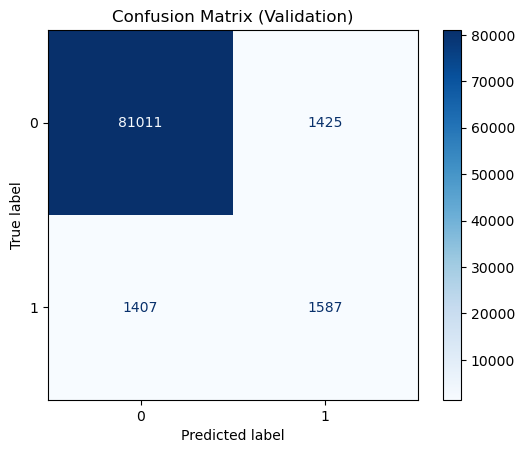

In [36]:
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix (Validation)')
plt.grid(False)

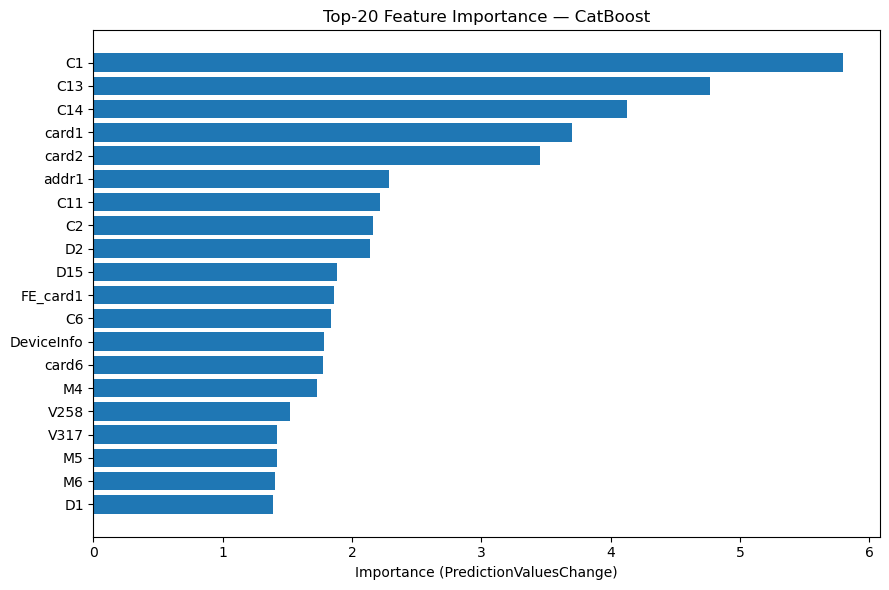

In [37]:
fi = model.get_feature_importance(type="PredictionValuesChange")

fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": fi
}).sort_values("importance", ascending=False)

top_n = 20
top_fi = fi_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Importance (PredictionValuesChange)")
plt.title("Top-20 Feature Importance — CatBoost")
plt.tight_layout()